# 2. Embeddings con sentence-transformers

In [1]:
from sentence_transformers import SentenceTransformer
import torch
import re
import numpy as np
import pandas as pd

In [2]:
# Definimos que use el GPU para esta monda
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Usando: {device}")

Usando: cuda


In [3]:
model = SentenceTransformer("paraphrase-multilingual-MiniLM-L12-v2", device=device)
print("Modelo cargado. Dimensión de salida:", model.get_embedding_dimension())

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Modelo cargado. Dimensión de salida: 384


Cargamos los datasets

In [4]:
conversaciones = pd.read_parquet("../data/dataset_conversaciones/dataset_50k_anonymized.parquet")

In [5]:
conv_full = (conversaciones
    .sort_values(["conv_id", "date"])
    .groupby("conv_id")
    .agg({
        "user_id": "first",
        "input": lambda x: " ".join(x.astype(str)),
        "channel_source": "first"
    })
    .reset_index()
    .rename(columns={"input": "texto_usuario"}))

print(f"Conversaciones reconstruidas: {len(conv_full):,}")
conv_full.head(2)

Conversaciones reconstruidas: 24,119


,conv_id,user_id,texto_usuario,channel_source
0,0000ACA6-AA00-4227-BCE7-5E78C2742D88,USR-12729,Cuál es su tasa de interés para el crédito de ...,1
1,00043647-377f-4528-b2b3-425afd81f6bd,USR-11649,No le deja seleccionar el cobro para hacer la ...,1


In [6]:
def limpiar(t):
    t = str(t).lower()
    t = re.sub(r"\s+", " ", t)
    t = re.sub(r"http\S+", "", t)
    return t.strip()
    
conv_full["texto_limpio"] = conv_full["texto_usuario"].apply(limpiar)

# Filtrar conversaciones muy cortas (ruido)
conv_full = conv_full[conv_full["texto_limpio"].str.len() > 10].reset_index(drop=True)
print(f"Conversaciones tras filtrar: {len(conv_full):,}")

Conversaciones tras filtrar: 23,791


In [7]:
textos = conv_full["texto_limpio"].tolist()

embeddings = model.encode(
    textos,
    batch_size=64,
    show_progress_bar=True,
    convert_to_numpy=True,
    normalize_embeddings=True
)

print(f"Shape embeddings: {embeddings.shape}")
# Esperado: (n_conversaciones, 384)

Batches:   0%|          | 0/372 [00:00<?, ?it/s]

Shape embeddings: (23791, 384)


In [8]:
np.save("embeddings_conv.npy", embeddings)
conv_full[["conv_id", "user_id"]].to_parquet("conv_index.parquet", index=False)
print("Guardado")

Guardado



# 3. Clustering conversacional con BERTopic

## Primera versión

In [9]:
print("Embeddings shape:", embeddings.shape)
print("Conv full:", conv_full.shape)
print("Columnas conv_full:", conv_full.columns.tolist())

Embeddings shape: (23791, 384)
Conv full: (23791, 5)
Columnas conv_full: ['conv_id', 'user_id', 'texto_usuario', 'channel_source', 'texto_limpio']


Cargamos las librerias necesarias

In [10]:
from bertopic import BERTopic
from umap import UMAP
from hdbscan import HDBSCAN
from sklearn.feature_extraction.text import CountVectorizer

Configurar componentes de BERTopic

In [11]:
# UMAP: reduce dimensiones antes de clusterizar
umap_model = UMAP(
    n_neighbors=15,
    n_components=10,
    min_dist=0.0,
    metric="cosine",
    random_state=42
)

# HDBSCAN: clustering por densidad
hdbscan_model = HDBSCAN(
    min_cluster_size=80,        # mínimo de convs para formar cluster
    min_samples=10,
    metric="euclidean",
    cluster_selection_method="eom",
    prediction_data=True
)

print("Modelos configurados")


Modelos configurados


In [12]:
from sklearn.feature_extraction.text import CountVectorizer

# Stopwords en español + algunas específicas del dominio
stopwords_es = [
    "de", "la", "que", "el", "en", "y", "a", "los", "del", "se", "las",
    "por", "un", "para", "con", "no", "una", "su", "al", "lo", "como",
    "más", "pero", "sus", "le", "ya", "o", "este", "sí", "porque",
    "esta", "entre", "cuando", "muy", "sin", "sobre", "también", "me",
    "hasta", "hay", "donde", "quien", "desde", "todo", "nos", "durante",
    "todos", "uno", "les", "ni", "contra", "otros", "ese", "eso", "ante",
    "ellos", "e", "esto", "mí", "antes", "algunos", "qué", "unos", "yo",
    "otro", "otras", "otra", "él", "tanto", "esa", "estos", "mucho",
    "quienes", "nada", "muchos", "cual", "poco", "ella", "estar", "estas",
    "algunas", "algo", "nosotros", "mi", "mis", "tú", "te", "ti", "tu",
    "tus", "ellas", "nosotras", "vosotros", "vosotras", "os", "mío",
    "mía", "míos", "mías", "tuyo", "tuya", "tuyos", "tuyas", "suyo",
    "suya", "suyos", "suyas", "nuestro", "nuestra", "nuestros", "nuestras",
    "vuestro", "vuestra", "vuestros", "vuestras", "esos", "esas",
    "hola", "gracias", "buenos", "días", "buenas", "tardes", "noches"
]

vectorizer_model = CountVectorizer(stop_words=stopwords_es, ngram_range=(1, 2))
print("Vectorizer listo")

Vectorizer listo


In [13]:
topic_model = BERTopic(
    umap_model=umap_model,
    hdbscan_model=hdbscan_model,
    vectorizer_model=vectorizer_model,
    language="multilingual",
    calculate_probabilities=False,
    verbose=True
)

topics, _ = topic_model.fit_transform(
    documents=conv_full["texto_limpio"].tolist(),
    embeddings=embeddings
)

print(f"\nTópicos detectados: {len(set(topics)) - 1}")  # -1 excluye outliers
print(f"Conversaciones en outliers: {(np.array(topics) == -1).sum():,}")

2026-04-26 08:46:00,074 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-04-26 08:46:35,486 - BERTopic - Dimensionality - Completed ✓
2026-04-26 08:46:35,487 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-04-26 08:46:38,462 - BERTopic - Cluster - Completed ✓
2026-04-26 08:46:38,468 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-04-26 08:46:39,180 - BERTopic - Representation - Completed ✓



Tópicos detectados: 72
Conversaciones en outliers: 7,152


### Tópicos detectados

In [14]:
info = topic_model.get_topic_info()
print(f"Total tópicos: {len(info)}")
info.head(20)

Total tópicos: 73


,Topic,Count,Name,Representation,Representative_Docs
0,-1,7152,-1_tarjeta_si_puedo_crédito,"[tarjeta, si, puedo, crédito, cuenta, es, teng...","[cancelar tarjeta de crédito, cancelar tarjeta..."
1,0,1667,0_transferencia_banco_hey banco_hey,"[transferencia, banco, hey banco, hey, banregi...",[a qué banco pertenece hey banco que es hey ba...
2,1,568,1_enganche_auto_000_meses,"[enganche, auto, 000, meses, crédito auto, 60,...","[quiero un crédito de auto si 1,100,000.00 pla..."
3,2,464,2_reembolso_compra_dinero_devolución,"[reembolso, compra, dinero, devolución, reflej...",[tengo u. reembolso pendiente y aún no se me v...
4,3,445,3_cancelar tarjeta_cancelar_tarjeta crédito_qu...,"[cancelar tarjeta, cancelar, tarjeta crédito, ...","[cancelar tarjeta crédito, hola para cancelar ..."
5,4,431,4_tarjeta crédito_crédito_anualidad_efectivo,"[tarjeta crédito, crédito, anualidad, efectivo...","[efectivo de mi tarjeta de crédito, ¿puedo ret..."
6,5,414,5_cargo_reconocido_cargo reconocido_reportar,"[cargo, reconocido, cargo reconocido, reportar...","[reportar un cargo no reconocido, reportar car..."
7,6,408,6_cancelar_cancelar cuenta_quiero cancelar_can...,"[cancelar, cancelar cuenta, quiero cancelar, c...","[quiero cancelar mi cuenta, quiero cancelar mi..."
8,7,398,7_cliente_atención_atención cliente_clientes,"[cliente, atención, atención cliente, clientes...","[número de atención al cliente, número de aten..."
9,8,391,8_app_token_aplicación_móvil,"[app, token, aplicación, móvil, celular, entra...",[quiero hacer una transferencia y me dice que ...


In [15]:
for topic_id in info["Topic"].head(10).tolist():
    if topic_id == -1:
        continue
    print(f"\n{'='*60}")
    print(f"TÓPICO {topic_id} · {info[info.Topic==topic_id]['Count'].values[0]} convs")
    print(f"Palabras clave: {[w for w, _ in topic_model.get_topic(topic_id)[:10]]}")
    print(f"\nEjemplo de conversación:")
    ejemplos = [conv_full.iloc[i]['texto_limpio'][:300] 
                for i in range(len(topics)) if topics[i] == topic_id][:2]
    for e in ejemplos:
        print(f"  → {e}")


TÓPICO 0 · 1667 convs
Palabras clave: ['transferencia', 'banco', 'hey banco', 'hey', 'banregio', 'cuenta', 'clabe', 'transferencias', 'clave', 'hice']

Ejemplo de conversación:
  → transferencias programadas
  → dónde me pueden depositar

TÓPICO 1 · 568 convs
Palabras clave: ['enganche', 'auto', '000', 'meses', 'crédito auto', '60', '60 meses', 'mil', 'crédito', '48']

Ejemplo de conversación:
  → si cumplo con esos requisitos soy sujeto a crédito automotriz? si monto total 499,900, plazo 60 meses, enganche 100,000 pesos, año vehículo 2026 me interesa estaré en espera de la invitación
  → hola me interesa un credito de auto recibo un ingreso mensual de $22,000 uno de 60 meses $90,000 de crédito y un enganche de $8,000 como solciito este credito ay que hace algunos años quede mal en buro y hasta ahorita nose como resolver eso

TÓPICO 2 · 464 convs
Palabras clave: ['reembolso', 'compra', 'dinero', 'devolución', 'reflejado', 'rembolso', 'pago', 'hice', 'hicieron', 'ha']

Ejemplo de conve

In [16]:
fig = topic_model.visualize_topics()
fig.show()

In [17]:
fig = topic_model.visualize_barchart(top_n_topics=12, n_words=8)
fig.show()

In [18]:
conv_full["topic"] = topics
conv_full["topic_name"] = conv_full["topic"].map(
    dict(zip(info["Topic"], info["Name"]))
)

print(conv_full[["conv_id", "user_id", "topic", "topic_name"]].head(10))

                                conv_id    user_id  topic  \
0  0000ACA6-AA00-4227-BCE7-5E78C2742D88  USR-12729     -1   
1  00043647-377f-4528-b2b3-425afd81f6bd  USR-11649     -1   
2  000502c2-288c-41f6-b751-a8b45a376a81  USR-09092     24   
3  000DD932-B649-41FF-9B2A-EB08B33F5072  USR-10602     12   
4  00149741-F4D6-4BC9-B8FB-6FFD398FD73F  USR-01560      7   
5  0014FB3D-727F-43B8-9E9C-1F63C0303818  USR-06635     -1   
6  001ea1e9-93aa-4d59-b19f-eb11bb3aa312  USR-00940     16   
7  00221607-cdb2-47f2-a9ac-913d4c7744c6  USR-09344     48   
8  00243113-211B-4123-8C2F-2AEDC69D452E  USR-09850     26   
9  002D9FA0-5064-407C-B4CE-480825090DD5  USR-10380     32   

                                          topic_name  
0                        -1_tarjeta_si_puedo_crédito  
1                        -1_tarjeta_si_puedo_crédito  
2            24_aumento_aumentar_línea_línea crédito  
3               12_teléfono_contacto_recarga_celular  
4       7_cliente_atención_atención cliente_clientes 

In [19]:
# Después de ver los tópicos, decides cuántos perfiles macro quieres
# Por ejemplo: agrupar 30 tópicos en 8 perfiles

# Opción automática: que BERTopic los reduzca por similitud
topic_model.reduce_topics(
    docs=conv_full["texto_limpio"].tolist(),
    nr_topics=10  # número objetivo de perfiles
)

# Re-asignar tópicos
conv_full["perfil_conv"] = topic_model.topics_
info_reducido = topic_model.get_topic_info()
print(info_reducido)

2026-04-26 08:46:43,403 - BERTopic - Topic reduction - Reducing number of topics
2026-04-26 08:46:43,429 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-04-26 08:46:44,151 - BERTopic - Representation - Completed ✓
2026-04-26 08:46:44,157 - BERTopic - Topic reduction - Reduced number of topics from 73 to 10


   Topic  Count                                             Name  \
0     -1   7152                      -1_tarjeta_si_puedo_crédito   
1      0   6791             0_tarjeta_crédito_si_tarjeta crédito   
2      1   3964               1_transferencia_banco_puedo_cuenta   
3      2   2212                          2_token_app_apple_puedo   
4      3   1614                 3_asesor_atención_hablar_cliente   
5      4   1490              4_cuenta_clabe_estado_estado cuenta   
6      5    219    5_actualizar_app_actualización_actualizar app   
7      6    161            6_codi_pagar codi_codi cómo_pago codi   
8      7    106  7_domicilio_dirección_cambiar_cambiar domicilio   
9      8     82        8_plástico_nuevo_plástico tarjeta_tarjeta   

                                      Representation  \
0  [tarjeta, si, puedo, crédito, cuenta, es, teng...   
1  [tarjeta, crédito, si, tarjeta crédito, quiero...   
2  [transferencia, banco, puedo, cuenta, dinero, ...   
3  [token, app, apple, pued

In [20]:
for pid in sorted(set(conv_full["perfil_conv"])):
    if pid == -1:
        continue
    palabras = [w for w, _ in topic_model.get_topic(pid)[:8]]
    n = (conv_full["perfil_conv"] == pid).sum()
    print(f"\nPerfil {pid} · {n} convs")
    print(f"  Palabras: {', '.join(palabras)}")



Perfil 0 · 6791 convs
  Palabras: tarjeta, crédito, si, tarjeta crédito, quiero, puedo, auto, meses

Perfil 1 · 3964 convs
  Palabras: transferencia, banco, puedo, cuenta, dinero, hey, es, si

Perfil 2 · 2212 convs
  Palabras: token, app, apple, puedo, pay, apple pay, cuenta, es

Perfil 3 · 1614 convs
  Palabras: asesor, atención, hablar, cliente, cargo, número, teléfono, clientes

Perfil 4 · 1490 convs
  Palabras: cuenta, clabe, estado, estado cuenta, movimiento, ver, nip, puedo

Perfil 5 · 219 convs
  Palabras: actualizar, app, actualización, actualizar app, aplicación, versión, actualizo, actualizar aplicación

Perfil 6 · 161 convs
  Palabras: codi, pagar codi, codi cómo, pago codi, pagar, código, qr, codi codi

Perfil 7 · 106 convs
  Palabras: domicilio, dirección, cambiar, cambiar domicilio, cambio domicilio, domicilio cómo, cambio, cambiar dirección

Perfil 8 · 82 convs
  Palabras: plástico, nuevo, plástico tarjeta, tarjeta, plastico, plástico nuevo, costo, si


In [21]:
# Backup defensivo
import copy
topic_model_backup = copy.deepcopy(topic_model)
conv_full_backup = conv_full.copy()
print("Backup guardado")

Backup guardado


In [22]:
import copy
topic_model_v1 = copy.deepcopy(topic_model)
print("Backup v1 listo")

Backup v1 listo


## Segunda versión

In [23]:
# Stopwords (las que ya tenías)
stopwords_dominio = stopwords_es + [
    "tarjeta", "tarjetas", "crédito", "credito", "cuenta", "cuentas",
    "puedo", "quiero", "tengo", "necesito", "saber", "puede", "favor",
    "hola", "buenos", "días", "buenas", "tardes", "gracias", "si", "es",
    "hey", "banco", "banregio", "ayuda", "ayudar", "información",
    "cliente", "clientes", "servicio",
    "hacer", "tener", "ser", "estar", "ir", "ver", "dar", "si"
]

vectorizer_model = CountVectorizer(
    stop_words=stopwords_dominio, 
    ngram_range=(1, 2),
    min_df=5
)

umap_model = UMAP(
    n_neighbors=10, n_components=10, min_dist=0.0,
    metric="cosine", random_state=42
)

hdbscan_model = HDBSCAN(
    min_cluster_size=20, min_samples=3,
    metric="euclidean", cluster_selection_method="leaf",
    prediction_data=True
)
print("Configuración v2 lista")

Configuración v2 lista


In [24]:
topic_model = BERTopic(
    umap_model=umap_model,
    hdbscan_model=hdbscan_model,
    vectorizer_model=vectorizer_model,
    language="multilingual",
    calculate_probabilities=False,
    verbose=True
)

topics, _ = topic_model.fit_transform(
    documents=conv_full["texto_limpio"].tolist(),
    embeddings=embeddings
)

info = topic_model.get_topic_info()
print(f"Total tópicos: {len(info) - 1}")
print(f"Outliers: {(np.array(topics) == -1).sum()}")
print(f"Tópico más grande: {info.iloc[1]['Count']} convs")

2026-04-26 08:46:57,194 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-04-26 08:47:12,394 - BERTopic - Dimensionality - Completed ✓
2026-04-26 08:47:12,395 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-04-26 08:47:13,644 - BERTopic - Cluster - Completed ✓
2026-04-26 08:47:13,653 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-04-26 08:47:14,153 - BERTopic - Representation - Completed ✓


Total tópicos: 377
Outliers: 7757
Tópico más grande: 159 convs


In [25]:
conv_full["topic"] = topics
print(conv_full["topic"].value_counts().head(10))

topic
-1    7757
 0     159
 1     146
 2     137
 3     136
 4     135
 5     126
 6     117
 7     112
 8     110
Name: count, dtype: int64


In [26]:
# Recorrer los 372 tópicos y obtener sus palabras clave
mapeo_data = []
for _, row in info.iterrows():
    tid = row["Topic"]
    if tid == -1:
        continue
    palabras = " ".join([w for w, _ in topic_model.get_topic(tid)[:10]])
    mapeo_data.append({
        "topic_id": tid,
        "count": row["Count"],
        "palabras": palabras
    })

df_mapeo = pd.DataFrame(mapeo_data)
print(f"Tópicos a mapear: {len(df_mapeo)}")
df_mapeo.head(20)

Tópicos a mapear: 377


,topic_id,count,palabras
0,0,159,auto invitación auto cómo auto auto requisitos...
1,1,146,hice transferencia transferencia hice transfer...
2,2,137,factura liquidar liquide auto liquidar automot...
3,3,136,actualizar actualizar aplicación actualización...
4,4,135,meses intereses intereses diferir compras mese...
5,5,126,préstamo prestamo préstamo personal 12 meses p...
6,6,117,numero teléfono oficiales pertenece número núm...
7,7,112,qr sat link pago pagos captura pago aclaración...
8,8,110,notificaciones llegan correos correo activar n...
9,9,104,garantizada garantizada aparece garantía garan...


In [27]:
def clasificar_perfil(palabras):
    p = palabras.lower()
    
    # ===== NUEVAS REGLAS DE ESTA RONDA =====
    if any(k in p for k in ["acciones", "acción", "vender", "comprar accion", "bolsa", "trading"]):
        return "Inversión bursátil"
    if any(k in p for k in ["tipo cambio", "dólares", "dolares", "dólar", "fx"]):
        return "Tipo de cambio / divisas"
    if any(k in p for k in ["saldo aparece", "saldo disponible", "consultar saldo", "veo saldo", "saldo"]):
        return "Consulta de saldo"
    if any(k in p for k in ["límite diario", "límite tope", "cuál límite", "cuánto límite", "monto total", "límite manejar"]):
        return "Consulta de límites"
    if any(k in p for k in ["mercado libre", "rechazada", "rechazaron", "fondos insuficientes"]):
        return "Compras rechazadas"
    if any(k in p for k in ["cuánto tarda", "tiempo tarda", "tarda caer", "cuanto tarda"]):
        return "Tiempos de procesamiento"
    if any(k in p for k in ["entregada", "entregaron", "entrega", "recibí", "recibido", "envío"]):
        return "Entrega de tarjeta"
    if any(k in p for k in ["usuario nombre", "cambiar usuario", "editar usuario", "alta usuario"]):
        return "Cambio de usuario"
    if any(k in p for k in ["números mismo", "cambian numeración", "nueva numeración"]):
        return "Cambio de números de tarjeta"
    if any(k in p for k in ["contrato", "carátula", "caratula"]):
        return "Contrato / carátula"
    if any(k in p for k in ["beneficiarios", "beneficiario"]):
        return "Beneficiarios"
    
    # ===== REGLAS RONDA ANTERIOR =====
    if any(k in p for k in ["referido", "referidos", "bono", "recompensa"]):
        return "Referidos / bonos"
    if any(k in p for k in ["pro cómo", "convierto pro", "soy pro", "activar pro", "hey pro"]):
        return "Hey Pro / suscripción"
    if any(k in p for k in ["menores", "menor", "hija", "hijo", "cuenta menor"]):
        return "Cuenta para menores"
    if any(k in p for k in ["moto", "motocicleta"]):
        return "Crédito moto"
    if any(k in p for k in ["perdí", "perdi", "perdió", "extraviada", "extravió", "clonaron", "robaron", "robada"]):
        return "Tarjeta perdida / robada"
    if any(k in p for k in ["estado cuenta", "estado mes", "descargar estado", "estado febrero", "estado enero", "obtener estado", "sacar estado"]):
        return "Estado de cuenta"
    if any(k in p for k in ["fecha límite", "fecha pago", "fecha corte", "día pago"]):
        return "Fechas de pago / corte"
    if any(k in p for k in ["solicitar", "solicito"]):
        return "Solicitud de productos"
    if any(k in p for k in ["eliminar", "borrar", "quitar", "darla baja", "doy baja", "baja"]):
        return "Eliminar / dar de baja"
    if any(k in p for k in ["activar", "activo", "activé"]):
        return "Activación"
    if any(k in p for k in ["portabilidad nómina", "portabilidad nomina", "potabilidad"]):
        return "Portabilidad de nómina"
    
    # ===== REGLAS ORIGINALES =====
    if any(k in p for k in ["préstamo personal", "prestamo", "préstamo"]):
        return "Crédito personal"
    if any(k in p for k in ["negocio", "negocios", "pyme"]):
        return "Crédito negocio"
    if any(k in p for k in ["auto", "automotriz", "factura", "vehículo"]):
        return "Crédito auto"
    if any(k in p for k in ["aumento", "aumentar línea", "línea crédito"]):
        return "Aumento de línea"
    if any(k in p for k in ["meses intereses", "msi", "diferir", "diferido"]):
        return "MSI / pagos diferidos"
    if any(k in p for k in ["garantizada", "garantía"]):
        return "Tarjeta garantizada"
    if any(k in p for k in ["cancelar", "cancelo", "cancelación"]):
        return "Cancelaciones"
    if any(k in p for k in ["bloqueada", "bloqueo", "desbloquear"]):
        return "Tarjeta bloqueada"
    if any(k in p for k in ["plástico", "reposición", "vencer", "venció", "física"]):
        return "Reposición de plástico"
    if any(k in p for k in ["transferencia", "transferir", "spei", "estados unidos", "extranjero", "remesa"]):
        return "Transferencias"
    if any(k in p for k in ["clabe", "clave interbancaria"]):
        return "CLABE / datos bancarios"
    if any(k in p for k in ["cargo reconocido", "reconozco", "aclaración", "movimiento", "reembolso", "rembolso", "devolución", "disputa"]):
        return "Disputas y aclaraciones"
    if any(k in p for k in ["apple pay", "google pay", "wallet", "apple", "samsung pay"]):
        return "Pagos digitales (wallet)"
    if any(k in p for k in ["codi", "qr"]):
        return "CoDi / QR"
    if any(k in p for k in ["actualizar", "actualización", "versión", "app", "aplicación"]):
        return "Problemas de app"
    if any(k in p for k in ["token", "clave", "contraseña", "incorrecto", "nip"]):
        return "Autenticación / token"
    if any(k in p for k in ["atención", "asesor", "humano", "ejecutivo", "hablar", "teléfono"]):
        return "Atención humana"
    if any(k in p for k in ["validación", "biométrica", "comprobante", "verificación", "selfie"]):
        return "Validación / onboarding"
    if any(k in p for k in ["domicilio", "dirección", "datos", "correo", "notificaciones"]):
        return "Datos personales / config"
    if any(k in p for k in ["depósito", "depositar", "efectivo", "oxxo", "farmacia"]):
        return "Depósitos en efectivo"
    if any(k in p for k in ["retiro", "cajero", "atm"]):
        return "Retiros / cajeros"
    if any(k in p for k in ["inversión", "ahorro", "rendimiento", "gat"]):
        return "Inversión"
    if any(k in p for k in ["anualidad", "recompensas", "beneficios", "promociones", "promoción", "cashback"]):
        return "Beneficios y recompensas"
    if any(k in p for k in ["seguro", "póliza", "vida", "compras"]):
        return "Seguros"
    if any(k in p for k in ["terminal", "tpv", "punto venta", "cobro"]):
        return "Negocios / terminal"
    if any(k in p for k in ["tiempo aire", "recarga", "telcel", "celular"]):
        return "Tiempo aire / recargas"
    if any(k in p for k in ["sat", "impuestos", "hacienda", "gobierno"]):
        return "Pagos a gobierno / SAT"
    if any(k in p for k in ["pal norte", "fan shop", "edición", "rayados"]):
        return "Tarjeta Pal Norte / Fan Shop"
    
    return "Otros"
# Aplicar
df_mapeo["perfil_macro"] = df_mapeo["palabras"].apply(clasificar_perfil)

# Ver resultado de la clasificación
print(df_mapeo["perfil_macro"].value_counts())
print(f"\nTópicos en 'Otros': {(df_mapeo['perfil_macro'] == 'Otros').sum()}")

perfil_macro
Atención humana                 28
Transferencias                  27
Disputas y aclaraciones         22
Otros                           18
Solicitud de productos          17
Crédito auto                    16
CLABE / datos bancarios         13
Cancelaciones                   13
Depósitos en efectivo           12
Reposición de plástico          12
Problemas de app                11
Autenticación / token           11
Pagos digitales (wallet)        11
Activación                      10
Tarjeta garantizada             10
Consulta de saldo               10
Eliminar / dar de baja           9
Tarjeta perdida / robada         8
Consulta de límites              7
Cuenta para menores              7
Entrega de tarjeta               7
MSI / pagos diferidos            6
Referidos / bonos                6
Retiros / cajeros                6
Datos personales / config        6
Tiempos de procesamiento         6
Estado de cuenta                 5
Beneficios y recompensas         5
Contrat

In [28]:
otros = df_mapeo[df_mapeo["perfil_macro"] == "Otros"].sort_values("count", ascending=False)
print(f"Tópicos en 'Otros' ({len(otros)}):\n")
for _, row in otros.head(20).iterrows():
    print(f"  T{row['topic_id']:>3} · {row['count']:>4} convs · {row['palabras'][:120]}")

Tópicos en 'Otros' (18):

  T 61 ·   60 convs · apartados aparecen apartado aparece apartado funciona veo apartados veo apartado dónde están encuentro apartado sección
  T 63 ·   59 convs · estado cómo estado veo estado estados estado cómo consigo podré encuentro dónde miro
  T137 ·   42 convs · pertenece stp eres persona moral somos moral eran nomina transfieren ahora
  T163 ·   39 convs · cuanto debo cuánto debo anual cat cobra cobrará debo 600 quisiera cuánto cuanto
  T181 ·   37 convs · cerrar cierro acabo abrir abri cono deseo definitivamente segunda sesión actualmente
  T203 ·   35 convs · número contacto contacto numero contacto número contactar contacto soporte contactar soporte dame número número número e
  T225 ·   32 convs · número dónde veo número encuentro número número numero numero cómo número dónde encuentro número checar dónde número
  T234 ·   31 convs · perfil validar perfil perfil transaccional transaccional validar está opción dónde está personal dónde está apartad

In [29]:
# Distribución por número de conversaciones (no de tópicos)
conv_full["perfil_macro"] = conv_full["topic"].map(
    dict(zip(df_mapeo["topic_id"], df_mapeo["perfil_macro"]))
)
conv_full.loc[conv_full["topic"] == -1, "perfil_macro"] = "Sin clasificar"

print("Distribución por # de conversaciones:")
print(conv_full["perfil_macro"].value_counts().head(20))
print(f"\nTotal convs: {len(conv_full):,}")
print(f"% Sin clasificar: {(conv_full['perfil_macro']=='Sin clasificar').mean():.1%}")
print(f"% Otros: {(conv_full['perfil_macro']=='Otros').mean():.1%}")

Distribución por # de conversaciones:
perfil_macro
Sin clasificar              7757
Atención humana             1226
Transferencias              1156
Solicitud de productos       960
Disputas y aclaraciones      929
Crédito auto                 898
Otros                        583
Problemas de app             552
CLABE / datos bancarios      536
Depósitos en efectivo        499
Cancelaciones                489
Tarjeta garantizada          487
Activación                   476
Consulta de saldo            476
Autenticación / token        461
Pagos digitales (wallet)     406
Reposición de plástico       402
MSI / pagos diferidos        371
Eliminar / dar de baja       346
Referidos / bonos            304
Name: count, dtype: int64

Total convs: 23,791
% Sin clasificar: 32.6%
% Otros: 2.5%


In [30]:
def consolidar_perfil(perfil):
    """Agrupa los 50 perfiles en ~22 macro-perfiles accionables."""
    
    productos_credito = {
        "Crédito auto", "Crédito personal", "Crédito negocio", 
        "Crédito moto", "Aumento de línea", "MSI / pagos diferidos"
    }
    tarjeta_gestion = {
        "Reposición de plástico", "Activación", "Tarjeta bloqueada",
        "Tarjeta perdida / robada", "Cancelaciones", 
        "Cambio de números de tarjeta", "Entrega de tarjeta"
    }
    inversiones = {"Inversión", "Inversión bursátil"}
    disputas = {"Disputas y aclaraciones", "Compras rechazadas"}
    saldo_limites = {"Consulta de saldo", "Consulta de límites", "Estado de cuenta"}
    hey_pro = {"Hey Pro / suscripción", "Referidos / bonos", 
               "Beneficios y recompensas"}
    onboarding = {"Validación / onboarding", "Cuenta para menores", 
                  "Cambio de usuario", "Portabilidad de nómina"}
    pagos_digitales = {"Pagos digitales (wallet)", "CoDi / QR", 
                       "Tipo de cambio / divisas"}
    config = {"Datos personales / config", "Fechas de pago / corte",
              "Beneficiarios", "Contrato / carátula"}
    
    if perfil in productos_credito: return "Productos de crédito"
    if perfil in tarjeta_gestion:   return "Gestión de tarjeta"
    if perfil in inversiones:        return "Inversión"
    if perfil in disputas:           return "Disputas y problemas con cargos"
    if perfil in saldo_limites:      return "Saldo y consultas"
    if perfil in hey_pro:            return "Hey Pro y beneficios"
    if perfil in onboarding:         return "Onboarding y datos personales"
    if perfil in pagos_digitales:    return "Pagos digitales"
    if perfil in config:             return "Configuración / contrato"
    
    # Quedan solos por ser claros y grandes
    if perfil in {"Transferencias", "Atención humana", "Solicitud de productos",
                  "Problemas de app", "Depósitos en efectivo", "Eliminar / dar de baja",
                  "Tarjeta garantizada", "Retiros / cajeros", "CLABE / datos bancarios",
                  "Autenticación / token", "Tiempos de procesamiento", "Negocios / terminal",
                  "Seguros", "Sin clasificar"}:
        return perfil
    
    if perfil == "Pagos a gobierno / SAT":      return "Pagos a gobierno"
    if perfil == "Tarjeta Pal Norte / Fan Shop": return "Tarjeta Pal Norte"
    if perfil == "Tiempo aire / recargas":       return "Tiempo aire"
    
    return "Otros"

conv_full["perfil_final"] = conv_full["perfil_macro"].apply(consolidar_perfil)

print("Distribución consolidada:")
print(conv_full["perfil_final"].value_counts())
print(f"\nTotal perfiles únicos: {conv_full['perfil_final'].nunique()}")

Distribución consolidada:
perfil_final
Sin clasificar                     7757
Gestión de tarjeta                 2153
Productos de crédito               1664
Atención humana                    1226
Transferencias                     1156
Disputas y problemas con cargos    1063
Saldo y consultas                   965
Solicitud de productos              960
Onboarding y datos personales       663
Hey Pro y beneficios                645
Configuración / contrato            638
Otros                               583
Pagos digitales                     567
Problemas de app                    552
CLABE / datos bancarios             536
Depósitos en efectivo               499
Tarjeta garantizada                 487
Autenticación / token               461
Eliminar / dar de baja              346
Retiros / cajeros                   254
Tiempos de procesamiento            193
Inversión                           185
Negocios / terminal                  97
Tarjeta Pal Norte                    74
T

In [31]:
# Perfil dominante por usuario
perfil_dom = (conv_full
    .groupby("user_id")["perfil_final"]
    .agg(lambda x: x.value_counts().index[0])
    .reset_index()
    .rename(columns={"perfil_final": "perfil_dominante"}))

# Distribución de perfiles por usuario (% en cada perfil)
perfil_dist = (conv_full
    .groupby(["user_id", "perfil_final"])
    .size()
    .unstack(fill_value=0))
perfil_dist = perfil_dist.div(perfil_dist.sum(axis=1), axis=0)
perfil_dist.columns = [f"pct_{c.replace(' ', '_').replace('/', '').replace('  ', '_').lower()}" 
                       for c in perfil_dist.columns]
perfil_dist = perfil_dist.reset_index()

# Diversidad
perfil_div = (conv_full
    .groupby("user_id")["perfil_final"]
    .nunique()
    .reset_index()
    .rename(columns={"perfil_final": "n_perfiles_tocados"}))

# # conversaciones
n_conv = (conv_full.groupby("user_id").size()
    .reset_index(name="n_conversaciones"))

# % por canal (asumiendo "2" es voz)
canal = (conv_full.groupby("user_id")["channel_source"]
    .agg(lambda x: (x.astype(str) == "2").mean())
    .reset_index()
    .rename(columns={"channel_source": "pct_voz"}))

# Unir todo
features_conv = (perfil_dom
    .merge(n_conv, on="user_id")
    .merge(perfil_div, on="user_id")
    .merge(canal, on="user_id")
    .merge(perfil_dist, on="user_id"))

print(f"Shape: {features_conv.shape}")
print(f"Usuarios con perfil: {features_conv['user_id'].nunique():,}")
print(f"\nDistribución de perfil dominante por usuario:")
print(features_conv["perfil_dominante"].value_counts())
features_conv.head(3)

Shape: (14928, 31)
Usuarios con perfil: 14,928

Distribución de perfil dominante por usuario:
perfil_dominante
Sin clasificar                     5153
Gestión de tarjeta                 1303
Productos de crédito               1150
Transferencias                      719
Atención humana                     718
Solicitud de productos              627
Disputas y problemas con cargos     624
Saldo y consultas                   552
Hey Pro y beneficios                415
Onboarding y datos personales       412
Configuración / contrato            370
Problemas de app                    355
Otros                               348
Pagos digitales                     346
CLABE / datos bancarios             300
Depósitos en efectivo               299
Tarjeta garantizada                 285
Autenticación / token               255
Eliminar / dar de baja              208
Retiros / cajeros                   146
Inversión                            99
Tiempos de procesamiento             92
Tarjeta P

,user_id,perfil_dominante,n_conversaciones,n_perfiles_tocados,pct_voz,pct_atención_humana,pct_autenticación__token,pct_clabe__datos_bancarios,pct_configuración__contrato,pct_depósitos_en_efectivo,...,pct_productos_de_crédito,pct_retiros__cajeros,pct_saldo_y_consultas,pct_sin_clasificar,pct_solicitud_de_productos,pct_tarjeta_pal_norte,pct_tarjeta_garantizada,pct_tiempo_aire,pct_tiempos_de_procesamiento,pct_transferencias
0,USR-00001,Hey Pro y beneficios,1,1,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,USR-00002,Productos de crédito,1,1,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,USR-00003,Atención humana,1,1,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [32]:
conv_full.to_parquet("conv_full_perfiles_finales.parquet", index=False)
features_conv.to_parquet("features_conv.parquet", index=False)
df_mapeo.to_csv("mapeo_topics_a_perfiles.csv", index=False)
print("✓ Guardado")
print(f"  - conv_full_perfiles_finales.parquet: {len(conv_full):,} filas")
print(f"  - features_conv.parquet: {len(features_conv):,} usuarios")

✓ Guardado
  - conv_full_perfiles_finales.parquet: 23,791 filas
  - features_conv.parquet: 14,928 usuarios


In [33]:
fig = topic_model.visualize_topics()
fig.show()

In [34]:
fig = topic_model.visualize_barchart(top_n_topics=12, n_words=8)
fig.show()

Construyendo índice de co-ocurrencias (puede tardar ~1-2 min)...
Vocabulario: 15,830 palabras | Pares: 557,883
Calculando Topic Coherence (NPMI)...

>>> Topic Coherence (NPMI) promedio: -0.7157
    (Rango [-1, 1] | >0.1 = aceptable | >0.2 = bueno)

>>> Topic Diversity: 0.5159
    (1,945 palabras únicas de 3,770 totales)
    (Rango [0, 1] | >0.6 = aceptable | >0.7 = bueno)

RESUMEN DE EVALUACIÓN
  Tópicos evaluados  : 377
  Topic Coherence    : -0.7157  (NPMI, top-10 words)
  Topic Diversity    : 0.5159  (top-10 words por tópico)

--- 10 tópicos más coherentes ---
 Topic  Count  coherence_npmi                                                                                      top_words
    60     60        0.216447                                         menores, hija, edad, hijo, menor, crear, abrir, perfil
   338     22       -0.025078 constancia, fiscal, constancia fiscal, retención, impuestos, documento, retenciones, situación
    83     53       -0.097972                 terminal,

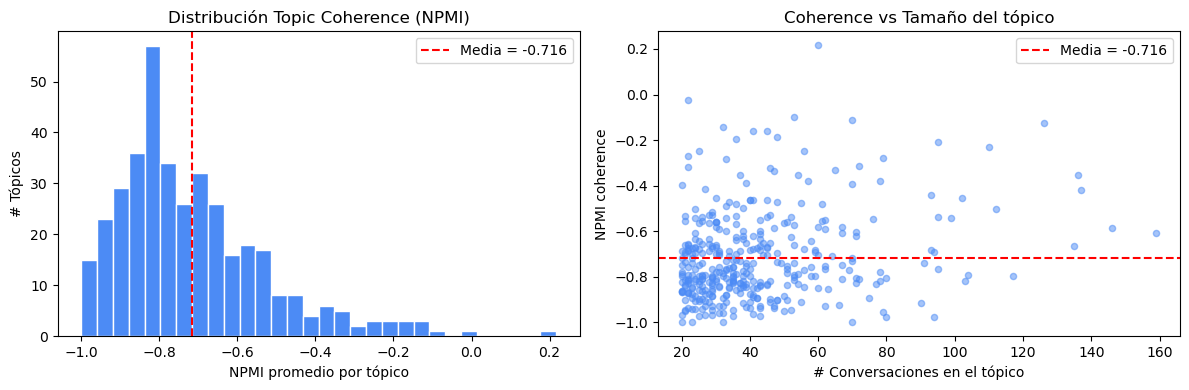

Gráfico guardado en topic_evaluation.png


In [35]:
# ============================================================
# 4. Evaluación de tópicos: Coherence (NPMI) + Diversity
# ============================================================

import numpy as np
from collections import defaultdict
from itertools import combinations

# -----------------------------------------------------------
# 4.1  Preparar corpus tokenizado (necesario para co-ocurrencias NPMI)
# -----------------------------------------------------------

def tokenizar(texto):
    """Tokenización simple: split sobre texto ya limpio."""
    return texto.lower().split()

corpus_tokens = [tokenizar(t) for t in conv_full["texto_limpio"].tolist()]

# -----------------------------------------------------------
# 4.2  Construir índice de co-ocurrencias en ventana deslizante
# -----------------------------------------------------------

def build_cooccurrence_index(corpus, window=10):
    """
    Cuenta co-ocurrencias de pares de palabras dentro de una
    ventana simétrica. También cuenta frecuencias individuales.
    """
    freq = defaultdict(int)      # freq[w]
    cofreq = defaultdict(int)    # cofreq[(w1, w2)] con w1 < w2
    n_docs = len(corpus)

    for doc in corpus:
        doc_words = list(dict.fromkeys(doc))   # únicos por doc
        for w in doc_words:
            freq[w] += 1
        for i, w1 in enumerate(doc):
            window_words = doc[max(0, i - window): i] + doc[i + 1: i + window + 1]
            for w2 in window_words:
                pair = tuple(sorted([w1, w2]))
                cofreq[pair] += 1

    return freq, cofreq, n_docs


print("Construyendo índice de co-ocurrencias (puede tardar ~1-2 min)...")
freq, cofreq, N = build_cooccurrence_index(corpus_tokens, window=10)
print(f"Vocabulario: {len(freq):,} palabras | Pares: {len(cofreq):,}")

# -----------------------------------------------------------
# 4.3  NPMI por par de palabras
# -----------------------------------------------------------

def npmi(w1, w2, freq, cofreq, N, eps=1e-10):
    """
    Normalized PMI ∈ [-1, 1].
    Valores cercanos a 1 = co-ocurren mucho más de lo esperado.
    """
    f1 = freq.get(w1, 0) / N
    f2 = freq.get(w2, 0) / N
    pair = tuple(sorted([w1, w2]))
    f12 = cofreq.get(pair, 0) / N

    if f12 < eps or f1 < eps or f2 < eps:
        return -1.0   # par nunca visto → penalizar

    pmi = np.log(f12 / (f1 * f2 + eps))
    norm = -np.log(f12 + eps)
    return pmi / (norm + eps)

# -----------------------------------------------------------
# 4.4  Topic Coherence promedio (NPMI-C_v simplificado)
# -----------------------------------------------------------

def topic_coherence_npmi(topic_model, freq, cofreq, N, top_n=10):
    """
    Para cada tópico calcula el NPMI promedio de todos los pares
    entre las top-N palabras clave.
    Retorna: dict {topic_id: coherence_score}, media global.
    """
    topic_info = topic_model.get_topic_info()
    scores = {}

    for _, row in topic_info.iterrows():
        tid = row["Topic"]
        if tid == -1:
            continue
        words = [w for w, _ in topic_model.get_topic(tid)[:top_n]]
        if len(words) < 2:
            scores[tid] = np.nan
            continue
        pairs_scores = [
            npmi(w1, w2, freq, cofreq, N)
            for w1, w2 in combinations(words, 2)
        ]
        scores[tid] = np.mean(pairs_scores)

    valid = [v for v in scores.values() if not np.isnan(v)]
    mean_coherence = np.mean(valid) if valid else np.nan
    return scores, mean_coherence


print("Calculando Topic Coherence (NPMI)...")
coherence_scores, mean_coherence = topic_coherence_npmi(
    topic_model, freq, cofreq, N, top_n=10
)
print(f"\n>>> Topic Coherence (NPMI) promedio: {mean_coherence:.4f}")
print("    (Rango [-1, 1] | >0.1 = aceptable | >0.2 = bueno)")

# -----------------------------------------------------------
# 4.5  Topic Diversity
# -----------------------------------------------------------

def topic_diversity(topic_model, top_n=10):
    """
    Proporción de palabras únicas sobre el total de palabras
    mostradas en todos los tópicos.
    TD = 1 → todos los tópicos usan vocabulario completamente distinto.
    TD cercano a 0 → muchas palabras se repiten entre tópicos.
    """
    topic_info = topic_model.get_topic_info()
    all_words = []

    for _, row in topic_info.iterrows():
        tid = row["Topic"]
        if tid == -1:
            continue
        words = [w for w, _ in topic_model.get_topic(tid)[:top_n]]
        all_words.extend(words)

    if not all_words:
        return np.nan

    unique_words = set(all_words)
    td = len(unique_words) / len(all_words)
    return td, unique_words, all_words


td, unique_words, all_words = topic_diversity(topic_model, top_n=10)
print(f"\n>>> Topic Diversity: {td:.4f}")
print(f"    ({len(unique_words):,} palabras únicas de {len(all_words):,} totales)")
print("    (Rango [0, 1] | >0.6 = aceptable | >0.7 = bueno)")

# -----------------------------------------------------------
# 4.6  Resumen consolidado + tópicos más y menos coherentes
# -----------------------------------------------------------

import pandas as pd

df_eval = topic_model.get_topic_info().copy()
df_eval = df_eval[df_eval["Topic"] != -1].copy()
df_eval["coherence_npmi"] = df_eval["Topic"].map(coherence_scores)
df_eval["top_words"] = df_eval["Topic"].apply(
    lambda tid: ", ".join([w for w, _ in topic_model.get_topic(tid)[:8]])
)

print("\n" + "="*65)
print("RESUMEN DE EVALUACIÓN")
print("="*65)
print(f"  Tópicos evaluados  : {len(df_eval):,}")
print(f"  Topic Coherence    : {mean_coherence:.4f}  (NPMI, top-10 words)")
print(f"  Topic Diversity    : {td:.4f}  (top-10 words por tópico)")
print("="*65)

print("\n--- 10 tópicos más coherentes ---")
print(
    df_eval.nlargest(10, "coherence_npmi")[["Topic", "Count", "coherence_npmi", "top_words"]]
    .to_string(index=False)
)

print("\n--- 10 tópicos menos coherentes ---")
print(
    df_eval.nsmallest(10, "coherence_npmi")[["Topic", "Count", "coherence_npmi", "top_words"]]
    .to_string(index=False)
)

# -----------------------------------------------------------
# 4.7  Histograma de coherence por tópico (opcional)
# -----------------------------------------------------------

import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histograma de coherence
axes[0].hist(df_eval["coherence_npmi"].dropna(), bins=30, color="#4C8BF5", edgecolor="white")
axes[0].axvline(mean_coherence, color="red", linestyle="--", label=f"Media = {mean_coherence:.3f}")
axes[0].set_title("Distribución Topic Coherence (NPMI)")
axes[0].set_xlabel("NPMI promedio por tópico")
axes[0].set_ylabel("# Tópicos")
axes[0].legend()

# Coherence vs tamaño del tópico
axes[1].scatter(
    df_eval["Count"], df_eval["coherence_npmi"],
    alpha=0.5, s=20, color="#4C8BF5"
)
axes[1].axhline(mean_coherence, color="red", linestyle="--", label=f"Media = {mean_coherence:.3f}")
axes[1].set_title("Coherence vs Tamaño del tópico")
axes[1].set_xlabel("# Conversaciones en el tópico")
axes[1].set_ylabel("NPMI coherence")
axes[1].legend()

plt.tight_layout()
plt.savefig("topic_evaluation.png", dpi=150, bbox_inches="tight")
plt.show()
print("Gráfico guardado en topic_evaluation.png")